## **Projekat iz predmeta Astrostatistika**

### **Uticaj spektralnog tipa zvezde na klasifikaciju egzoplaneta u habitabilnoj zoni prema Kopparapu modelu** 

### Letnji semestar 2026. godine

Student: Tamara Brujić

Mentor: prof. dr Anđelka Kovačević


Jedno od centralnih pitanja u proučavanju egzoplaneta jeste određivanje uslova pod kojima bi planeta mogla da poseduje tečnu vodu na površini. U tom kontekstu uvodi se pojam habitabilne zone, odnosno oblasti oko zvezde u kojoj planeta, pod odgovarajućim atmosferskim uslovima, prima dovoljnu količinu zračenja da voda može ostati u tečnom stanju. Habitabilna zona ne predstavlja direktan dokaz nastanjivosti planete, već samo prvi kriterijum za izdvajanje potencijalno interesantnih kandidata.

Položaj habitabilne zone zavisi prvenstveno od osobina matične zvezde, naročito od njene luminoznosti i efektivne temperature. Zbog toga se granice habitabilne zone ne mogu odrediti samo na osnovu orbitalne udaljenosti planete. Planeta na udaljenosti od $1 AU$ može biti u habitabilnoj zoni oko zvezde slične Suncu, ali ne i oko znatno hladnije ili toplije zvezde. U ovom radu koristi se Kopparapu model, koji daje analitički opis granica habitabilne zone preko efektivnog zvezdanog fluksa. Model omogućava da se za svaku zvezdu, na osnovu njene efektivne temperature i luminoznosti, izračunaju unutrašnje i spoljašnje granice konzervativne i optimistične habitabilne zone.

## **Kopparapu model**

Kopparapu uvodi model koji računa granice habitabilne zone koji se u prvoj iteraciji predstavlja preko fluksa izraženog putem polinomijalnog razvoja četvrtog stepena čiji je izraz: (_Kopparapu et al., 2014._) 

$$S_{eff} = S_{eff, \odot} + aT_* + bT_{*}^2 + cT_{*}^3 + dT_{*}^4$$

gde je:

$$T_{*} = T_{eff} - 5780$$

posle čega se fluks prevodi u udaljenost, odnosno habitabilnu zonu:

$$d = \sqrt{\frac{L_*/L_{\odot}}{S_{eff}}}$$

Na početku koda definišu se koeficijenti Kopparapu modela potrebni za računanje efektivnog zvezdanog fluksa na granicama habitabilne zone. Model ne daje direktno udaljenost granice u astronomskim jedinicama gde je efektivni fluks $S_{eff}$ izražen u jedinicama Sunčevog fluksa. Za svaku granicu habitabilne zone koristi se poseban skup koeficijenata $(S_{eff,\odot}, a, b, c, d)$, koji ulaze u izraz fluksa. Ova promenljiva predstavlja odstupanje efektivne temperature zvezde od Sunčeve efektivne temperature, pa se za zvezdu Sunčevog tipa izraz svodi na referentnu vrednost $(S_{eff,\odot})$.

U kodu su koeficijenti preuzeti iz _Kopparapu et al. (2014)_, dok je implementacija modela prilagođena potrebama ovog projekta. Granice habitabilne zone sa ovim koeficijentima su definisane kao: Recent Venus, Runaway Greenhouse, Maximum Greenhouse, Early Mars, kao i dodatnim Runaway Greenhouse granicama za planete različitih masa. U ovom radu za optimističnu habitabilnu zonu koriste se granice Recent Venus i Early Mars, dok se za konzervativnu habitabilnu zonu koriste Runaway Greenhouse i Maximum Greenhouse. Nakon izračunavanja fluksa, granice se pretvaraju u udaljenosti.


## **Računanje habitabilne zone iz kataloga Nasa Exoplanet Archive**

Podaci korišćeni dalje u radu su preuzeti iz _NASA Exoplanet Archive_ kataloga, iz tabele _Planetary Systems Composite Data_. Za svaku planetu korišćeni su parametri potrebni za primenu Kopparapu modela: efektivna temperatura zvezde, zvezdana luminoznost i velika poluosa orbite planete. U samoj tabeli je luminoznost data u logaritamskoj skali što treba pretvoriti u oblik $\frac{L}{L_{\odot}}$. Nakon čišćenja podataka i uklanjanja objekata sa parametrima koji nedostaju od gore navedenih, za svaku planetu izračunate su granice habitabilne zone i određeno je da li pripada konzervativnoj ili optimističnoj habitabilnoj zoni.

In [ ]:
"""Analiza habitabilnih zona egzoplaneta primenom Kopparapu modela."""

# pylint: disable=too-many-lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

In [41]:
# Učitavamo PSCompPars tabelu: jedan red po planeti
tab = NasaExoplanetArchive.query_criteria(  # pylint: disable=no-member
    table="pscomppars",
    select=(
        "pl_name,hostname,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,"
        "pl_rade,pl_bmasse,st_teff,st_tefferr1,st_tefferr2,"
        "st_lum,st_lumerr1,st_lumerr2,st_mass,st_rad,"
        "st_spectype,discoverymethod"
    ),
)
df = tab.to_pandas()

# df.info()
df.head()

,pl_name,hostname,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_rade,pl_bmasse,st_teff,st_tefferr1,st_tefferr2,st_lum,st_lumerr1,st_lumerr2,st_mass,st_rad,st_spectype,discoverymethod
0,Kepler-1597 b,Kepler-1597,0.04136,0.00037,-0.00037,1.06,1.20,6377.0,131.93,-114.19,0.43429,NaN,NaN,1.250,1.390,,Transit
1,Kepler-687 b,Kepler-687,0.13260,NaN,NaN,3.52,12.20,4841.0,93.00,-63.99,-0.56669,NaN,NaN,0.770,0.730,,Transit
2,Kepler-1596 b,Kepler-1596,0.32370,NaN,NaN,1.90,4.27,5706.0,76.54,-66.32,0.43061,NaN,NaN,0.950,0.920,,Transit
3,Kepler-692 b,Kepler-692,0.14950,NaN,NaN,3.11,9.85,5440.0,157.76,-162.00,-0.23346,NaN,NaN,0.900,0.860,,Transit
4,Kepler-150 c,Kepler-150,0.07300,NaN,NaN,3.69,13.20,5560.0,100.00,-100.00,-0.16141,NaN,NaN,0.956,0.939,,Transit


In [42]:
# Izbacuju se svi redovi koji nemaju neku od ove tri vrednosti koje nam trebaju za dalji račun
df_clean = df.dropna(subset=["st_teff", "st_lum", "pl_orbsmax"]).copy()

# Pretvaramo log-luminoznost u L/Lsun
df_clean["st_lum_solar"] = 10 ** df_clean["st_lum"]

# Kopparapu model najčešće koristimo u opsegu oko 2600-7200K
df_clean = df_clean[
    (df_clean["st_teff"] >= 2600) & (df_clean["st_teff"] <= 7200)
].copy()

# Uklanjamo vrednosti koje fizički nemaju smisla ako postoje
df_clean = df_clean[
    (df_clean["st_lum_solar"] > 0) & (df_clean["pl_orbsmax"] > 0)
].copy()

print("Broj planeta pre čišćenja:", len(df), " i nakon čišćenja:", len(df_clean))
# df_clean.head()

# Broj nedostajućih vrednosti po ključnom parametru
missing_by_column = df[["st_teff", "st_lum", "pl_orbsmax"]].isna().sum()

print("Broj nedostajućih vrednosti po parametru:")
print(missing_by_column)

Broj planeta pre čišćenja: 6324  i nakon čišćenja: 5524
Broj nedostajućih vrednosti po parametru:
st_teff       297
st_lum        315
pl_orbsmax    426
dtype: int64


Nakon čišćenja, može se primetiti da su najčešće odbačeni uzorci zbog nedostatka vrednosti velike poluose. Razlog tome može biti to da se ona najčešće računa iz trećeg Keplerovog zakona u čijem izrazu se koristi i masa zvezde koja često uz ostale parametre može biti samo procenjena. Tabela _pscomppars_ objedinjuje vrednosti iz literature što znači da ova vrednost može izostati čak i ako su dostupni svi parametri za njeno izračunavanje jer za određene radove nije bilo dovoljno relevantno da se određuje.

In [ ]:
# Kapparapu model

# Koeficijenti iz Kopparapu et al. modela
# Važe za različite granice habitabilne zone

kopparapu_coeffs = {
    # Venera je verovatno izgubila uslove za tečnu vodu relativno rano, pa se njen nekadašnji
    # položaj koristi kao empirijska,
    # optimistična unutrašnja granica ali je verovatno prevruće
    "recent_venus": {
        "Seff_sun": 1.776,
        "a": 2.136e-4,
        "b": 2.533e-8,
        "c": -1.332e-11,
        "d": -3.097e-15,
    },
    # Konzervativna unutrasnja granica, uslov kada planeta prima toliko zračenja da vodena
    # para pojačava efekat staklene bašte, temperatura raste, isparava još vode,
    # i proces teži da učini sistem nestabilanim
    "runaway_greenhouse": {
        "Seff_sun": 1.107,
        "a": 1.332e-4,
        "b": 1.580e-8,
        "c": -8.308e-12,
        "d": -1.931e-15,
    },
    # Ovo je konzervativna spoljašnja granica, jer na spoljašnjoj
    #  ivici HZ planeta prima manje zračenja. Da bi ostala dovoljno topla,
    #  potreban joj je jak efekat staklene bašte, najčešće zbog CO2
    "maximum_greenhouse": {
        "Seff_sun": 0.356,
        "a": 6.171e-5,
        "b": 1.698e-9,
        "c": -3.198e-12,
        "d": -5.575e-16,
    },
    # Ovo je optimistična spoljašnja granica
    "early_mars": {
        "Seff_sun": 0.320,
        "a": 5.547e-5,
        "b": 1.526e-9,
        "c": -2.874e-12,
        "d": -5.011e-16,
    },
    # Specifične granice navedene u originalnom kodu, za različite mase planeta, 5 i 0.1 mase Zemlje
    # Za ovaj konkretan projekat ove granice nisu korišćene jer je bilo dovoljno odrediti osnovne
    # ali su ostavljene za potencijalno proširenje analize
    "runaway_greenhouse_5Me": {
        "Seff_sun": 1.188,
        "a": 1.433e-4,
        "b": 1.707e-8,
        "c": -8.968e-12,
        "d": -2.084e-15,
    },
    "runaway_greenhouse_01Me": {
        "Seff_sun": 0.99,
        "a": 1.209e-4,
        "b": 1.404e-8,
        "c": -7.418e-12,
        "d": -1.713e-15,
    },
}

In [ ]:
# fluks koji planeta prima od svoje zvezde, izražen u jedinicama Sunčevog fluksa koji
# Zemlja prima danas prema Kopparapu modelu.
def kopparapu_seff(teff, limit_name):
    """Računa efektivni zvezdani fluks za izabranu granicu habitabilne zone."""

    # teff: efektivna temperatura zvezde u K
    # limit_name: ime granice iz kopparapu_coeffs

    coeff = kopparapu_coeffs[limit_name]
    t_star = teff - 5780.0

    s_eff = (
        coeff["Seff_sun"]
        + coeff["a"] * t_star
        + coeff["b"] * t_star**2
        + coeff["c"] * t_star**3
        + coeff["d"] * t_star**4
    )

    return s_eff


# Moramo da radimo sa efektivnom temperaturom a ne samo ukupnom luminoznošću jer zrače u
# različitim delovima spektra pa i planeta apsorbuje to zračenje drugačije

# Računa udaljenost HZ granice u AU.


def hz_distance(luminosity, teff, limit_name):
    """Računa udaljenost izabrane granice habitabilne zone u astronomskim jedinicama."""
    # luminosity: luminoznost zvezde u jedinicama Sunčeve luminoznosti
    # teff: efektivna temperatura zvezde u K
    # limit_name: ime Kopparapu granice

    seff = kopparapu_seff(teff, limit_name)
    distance = np.sqrt(luminosity / seff)

    return distance

In [ ]:
# Za svaku planetu sada uzimamo učitane vrednosti iz arhive za luminoznost i temperaturu zvezde
# nakon čega prethodno definisane 4 HZ računamo za svaku ponaosob na kojoj je udaljenosti
df_clean["hz_recent_venus"] = hz_distance(
    df_clean["st_lum_solar"], df_clean["st_teff"], "recent_venus"
)

df_clean["hz_runaway_greenhouse"] = hz_distance(
    df_clean["st_lum_solar"], df_clean["st_teff"], "runaway_greenhouse"
)

df_clean["hz_maximum_greenhouse"] = hz_distance(
    df_clean["st_lum_solar"], df_clean["st_teff"], "maximum_greenhouse"
)

df_clean["hz_early_mars"] = hz_distance(
    df_clean["st_lum_solar"], df_clean["st_teff"], "early_mars"
)

In [46]:
# Klasifikacija planeta, pripadanje HZ
# Uzimamo vrednosti velike poluose učitanih egzoplaneta
a_planet = df_clean["pl_orbsmax"]

# Nalazi se u granici konzervativne hz, da ili ne
df_clean["in_conservative_hz"] = (a_planet >= df_clean["hz_runaway_greenhouse"]) & (
    a_planet <= df_clean["hz_maximum_greenhouse"]
)

# U granici optimističke hz
df_clean["in_optimistic_hz"] = (a_planet >= df_clean["hz_recent_venus"]) & (
    a_planet <= df_clean["hz_early_mars"]
)

# Pošto imamo vrednosti koje su definisane kao da ili ne, konkretizujemo tekstutualno kroz uslove
# koji se nadovezuju kojoj kategoriji habitabilne zone pripada planeta


def classify_hz(row):
    """Klasifikuje planetu prema njenom položaju u habitabilnoj zoni."""
    a = row["pl_orbsmax"]

    if row["in_conservative_hz"]:
        return "conservative HZ"

    if row["in_optimistic_hz"]:
        return "optimistic HZ only"

    if a < row["hz_recent_venus"]:
        return "too close"

    if a > row["hz_early_mars"]:
        return "too far"

    return "between boundaries"


df_clean["hz_class"] = df_clean.apply(classify_hz, axis=1)
# df_clean["in_conservative_hz"].mean() * 100

In [47]:
# Čuvam tabelu sa planetama koje su ispunile uslov da se na njih može primeniti model
df_clean.to_csv("exoplanets_kopparapu_hz.csv", index=False)

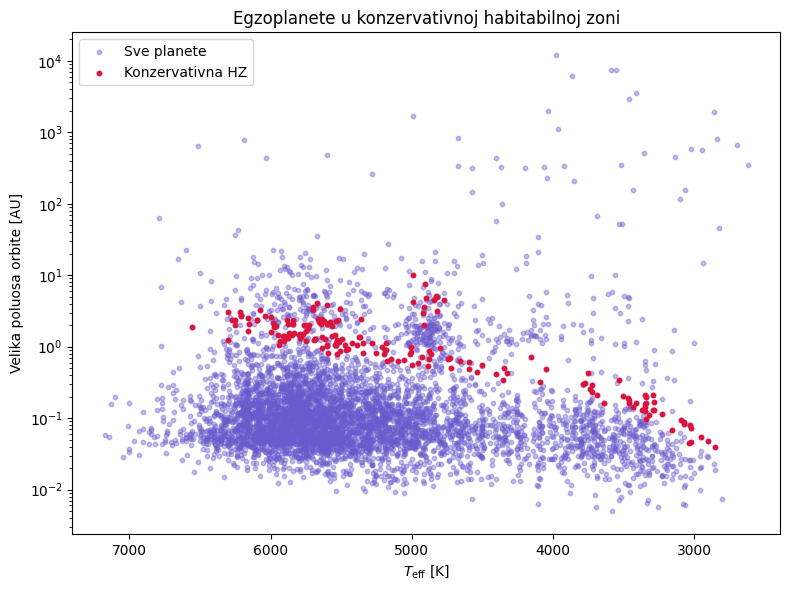

In [ ]:
plt.figure(figsize=(8, 6), dpi=160)

plt.scatter(
    df_clean["st_teff"],
    df_clean["pl_orbsmax"],
    s=10,
    alpha=0.4,
    color="slateblue",
    label="Sve planete",
)

plt.scatter(
    df_clean.loc[df_clean["in_conservative_hz"], "st_teff"],
    df_clean.loc[df_clean["in_conservative_hz"], "pl_orbsmax"],
    s=10,
    color="crimson",
    label="Konzervativna HZ",
)


plt.xlabel(r"$T_{\mathrm{eff}}$ [K]")
plt.ylabel("Velika poluosa orbite [AU]")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.legend()
plt.title("Egzoplanete u konzervativnoj habitabilnoj zoni")

plt.tight_layout()
plt.show()

Može se primetiti da se kandidati za konzervativnu HZ ne nalaze na jednoj fiksnoj orbitalnoj udaljenosti, već prate zavisnost od efektivne temperature zvezde. Kod toplijih zvezda, odnosno zvezda sa većim $T_{eff}$, konzervativna habitabilna zona nalazi se na većim orbitalnim udaljenostima. Kod hladnijih zvezda, naročito M tipa, habitabilna zona je pomerena bliže zvezdi, pa se crvene tačke pojavljuju na manjim vrednostima velike poluose. To je očekivano, jer hladnije zvezde imaju manju luminoznost, pa planeta mora biti bliže zvezdi da bi primila dovoljno zračenja za uslove habitabilne zone.

Takođe se vidi da je većina detektovanih planeta smeštena na malim orbitalnim udaljenostima, ispod približno $0.1 – 0.2AU$. Veliki broj tih planeta nije označen kao HZ kandidat, što znači da su za svoje zvezde uglavnom preblizu unutrašnjoj granici habitabilne zone.

In [49]:
# Broj planeta pre i posle čišćenja podataka
n_total_original = len(df)
n_after_dropna = len(df_clean)
n_removed_missing = n_total_original - n_after_dropna

# Broj planeta u različitim kategorijama HZ
n_conservative = df_clean["in_conservative_hz"].sum()

n_optimistic_only = (
    df_clean[
        "in_optimistic_hz"
    ]  # One koje su u optimističkoj ali izbacuje one iz konzervativne
    & ~df_clean["in_conservative_hz"]
).sum()

n_not_hz = (
    ~df_clean["in_optimistic_hz"]
).sum()  # Broji sve planete koje nisu u optimističkoj zoni

# Tabela sa rezultatima
tabela = pd.DataFrame(
    {
        "Kategorija": [
            "Konzervativna HZ",
            "Samo optimistična HZ",
            "Van habitabilne zone",
            "Izbačeno zbog nedostajućih podataka",
        ],
        "Broj planeta": [
            n_conservative,
            n_optimistic_only,
            n_not_hz,
            n_removed_missing,
        ],
    }
)

tabela["Procenat [%]"] = [
    np.round(100 * n_conservative / n_after_dropna, 2),
    np.round(100 * n_optimistic_only / n_after_dropna, 2),
    np.round(100 * n_not_hz / n_after_dropna, 2),
    np.round(100 * n_removed_missing / n_total_original, 2),
]

print(tabela)

                            Kategorija  Broj planeta  Procenat [%]
0                     Konzervativna HZ           181          3.28
1                 Samo optimistična HZ            92          1.67
2                 Van habitabilne zone          5251         95.06
3  Izbačeno zbog nedostajućih podataka           800         12.65


## **Bootstrap analiza udela planeta u habitabilnoj zoni**

Sama klasifikacija planeta u konzervativnu ili optimističnu habitabilnu zonu daje samo jednu vrednost udela kandidata u posmatranom uzorku. Međutim, pošto radimo sa konačnim katalogom detektovanih egzoplaneta, taj udeo ne treba posmatrati kao apsolutno tačnu vrednost. Kada bi se uzorak planeta malo promenio, na primer zbog novih otkrića, drugačijeg izbora podataka ili uklanjanja pojedinih objekata, dobijeni procenat planeta u habitabilnoj zoni mogao bi se blago promeniti. Zbog toga je potrebno proceniti koliko je rezultat stabilan u odnosu na promene uzorka.

Ideja bootstrap metode je da se iz postojećeg očišćenog uzorka N planeta nasumično izvlači novi uzorak koji je iste veličine ali sa ponavljanjem. Za njega se potom računa ponovo udeo HZ planeta i pošto se to iterira mnogo puta dobija se raspodela mogućih vrednosti udela. Iz te raspodele mogu se proceniti standardna greška i interval poverenja za udeo HZ kandidata.

Ovaj korak je važan jer uvodi statističku neodređenost u rezultat Kopparapu klasifikacije. Umesto da se zaključi samo koliki procenat planeta pripada habitabilnoj zoni, bootstrap analiza omogućava da se proceni koliko je taj procenat pouzdan i da li je razlika između konzervativne i optimistične definicije habitabilne zone stabilna u odnosu na promene koje nastaju pri ponovnom uzorkovanju podataka.

In [50]:
# Definisanje funkcije
def bootstrap_fraction(data, column, n_bootstrap):
    """Generiše bootstrap raspodelu udela za izabranu kolonu."""
    n = len(data)
    bootstrap_values = []

    for _ in range(n_bootstrap):
        sample = data.sample(n=n, replace=True)

        fraction = sample[column].mean()
        bootstrap_values.append(fraction)

    return np.array(bootstrap_values)

In [51]:
# Njena primena na konzervativnu i optimističnu HZ
boot_conservative = bootstrap_fraction(
    df_clean,
    "in_conservative_hz",
    n_bootstrap=5000,
)

boot_optimistic = bootstrap_fraction(
    df_clean,
    "in_optimistic_hz",
    n_bootstrap=5000,
)

In [ ]:
def summarize_bootstrap(bootstrap_values):
    """Računa srednju vrednost, standardnu devijaciju i 95% interval pouzdanosti."""
    mean_value = np.mean(bootstrap_values)
    std_value = np.std(bootstrap_values, ddof=1)

    lower_95 = np.percentile(bootstrap_values, 2.5)
    upper_95 = np.percentile(bootstrap_values, 97.5)

    return mean_value, std_value, lower_95, upper_95

In [53]:
cons_mean, cons_std, cons_low, cons_high = summarize_bootstrap(boot_conservative)
opt_mean, opt_std, opt_low, opt_high = summarize_bootstrap(boot_optimistic)


bootstrap_summary = pd.DataFrame(
    {
        "Kategorija": ["Konzervativna HZ", "Optimistična HZ"],
        "Udeo [%]": [100 * cons_mean, 100 * opt_mean],
        "Bootstrap std [%]": [100 * cons_std, 100 * opt_std],
        "95% CI donja granica [%]": [100 * cons_low, 100 * opt_low],
        "95% CI gornja granica [%]": [100 * cons_high, 100 * opt_high],
    }
)

np.round(bootstrap_summary, 2)

,Kategorija,Udeo [%],Bootstrap std [%],95% CI donja granica [%],95% CI gornja granica [%]
0,Konzervativna HZ,3.28,0.24,2.82,3.77
1,Optimistična HZ,4.94,0.30,4.38,5.54


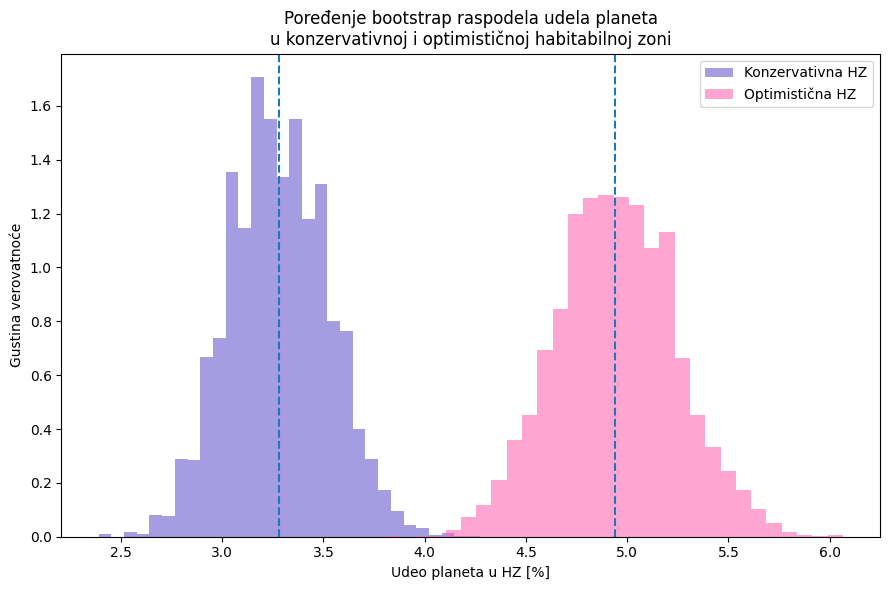

In [ ]:
plt.figure(figsize=(9, 6), dpi=160)

plt.hist(
    100 * boot_conservative,
    bins=30,
    alpha=0.6,
    density=True,
    color="slateblue",
    label="Konzervativna HZ",
)

plt.hist(
    100 * boot_optimistic,
    bins=30,
    alpha=0.6,
    density=True,
    color="hotpink",
    label="Optimistična HZ",
)

plt.axvline(100 * cons_mean, linestyle="--")
plt.axvline(100 * opt_mean, linestyle="--")

plt.xlabel("Udeo planeta u HZ [%]")
plt.ylabel("Gustina verovatnoće")
plt.title(
    "Poređenje bootstrap raspodela udela planeta\n"
    "u konzervativnoj i optimističnoj habitabilnoj zoni"
)
plt.legend()

plt.tight_layout()
plt.show()

Dobijene bootstrap raspodele su centrirane oko istih vrednosti koje su dobijene direktnom Kopparapu klasifikacijom: $3.22\%$ za konzervativnu HZ i $4.84\%$ za optimističnu HZ. To pokazuje da bootstrap analiza ne menja osnovni rezultat modela, već mu dodaje procenu statističke neizvesnosti.

Za konzervativnu HZ dobijena je bootstrap standardna devijacija od $0.24\%$, dok $95\%$ interval pouzdanosti iznosi od $2.77\%$ do $3.69\%$. Za optimističnu HZ standardna devijacija je $0.29\%$, a $95\%$ interval pouzdanosti je od $4.28\%$ do $5.40\%$. Raspodele su relativno uske, sa komentarom da je za optimističnu raspodela šira, ali ovo načelno znači da se procenjeni udeo planeta u HZ ne menja drastično pri ponovnom uzorkovanju. Istovremeno, optimistična HZ ima veći udeo kandidata, što je očekivano jer obuhvata širi interval orbitalnih udaljenosti od konzervativne zone. Dakle, Kopparapu model daje osnovnu klasifikaciju planeta, dok bootstrap analiza pokazuje da su dobijeni procenti stabilni za dati skup podataka i omogućava da se rezultat prikaže zajedno sa statističkom neizvesnošću.

## **Monte Carlo propagacija greške**

Bootstrap metoda rađena do sad je navedene parametre tretirala kao fiksne, proveravajući samo varijabilnost uzorka. Međutim, jasno je da treba uzeti u obzir i greške merenja samih parametara zvezde što dovodi do odgovora koliko je pouzdana klasifikacija pojedinačnih planeta. U svakoj Monte Carlo realizacije ideja je generisati nove moguće vrednosti iz skupa:

$$T_{eff}^{(n)} \sim \mathcal{N}(T_{eff}, \sigma_T)$$

i analogno tome za parametre $L_{*}$ i $a$. Potom će se za svaku računati granice habitabilne zone i udeo realizacija u kojima planeta pripada HZ će predstavljati procenu verovatnoće njene klasifikacije.

In [55]:
# Kolone koje su potrebne za Monte Carlo propagaciju grešaka
mc_columns = [
    "st_teff",
    "st_lum",
    "pl_orbsmax",
    "st_tefferr1",
    "st_lumerr1",
    "pl_orbsmaxerr1",
]

# Zadržavamo samo planete koje imaju sve centralne vrednosti i greške
df_mc = df_clean.dropna(subset=mc_columns).copy()

# Greške moraju biti različite od nule
df_mc = df_mc[
    (df_mc["st_tefferr1"].abs() > 0)
    & (df_mc["st_lumerr1"].abs() > 0)
    & (df_mc["pl_orbsmaxerr1"].abs() > 0)
].copy()

df_mc = df_mc.reset_index(drop=True)

print("Broj planeta u očišćenom uzorku:", len(df_clean))
print("Broj planeta sa svim potrebnim greškama:", len(df_mc))
print("Broj planeta izostavljenih iz Monte Carlo analize:", len(df_clean) - len(df_mc))

Broj planeta u očišćenom uzorku: 5524
Broj planeta sa svim potrebnim greškama: 2863
Broj planeta izostavljenih iz Monte Carlo analize: 2661


In [ ]:
# Definisana funkcija koja računa MC propagaciju greške za svaku planetu pojedinačno
# Kako u tabeli imamo dve greške predstavljene, ne kao standardnu devijaciju,
# već neodređenosti sa obe strane, pozitivne i negativne
# vrednosti koristiće se simetrična aproksimacija grešaka a finalni rezultat biće verovatnoća
# da li planeta pripada konzervativnoj ili optimističnoj HZ
def monte_carlo_hz(row, n_mc=1000):
    """Procenjuje verovatnoću pripadanja planete habitabilnoj zoni Monte Carlo metodom."""
    # Standardne devijacije uzimamo kao apsolutne vrednosti grešaka
    sigma_teff = abs(row["st_tefferr1"])
    sigma_log_lum = abs(row["st_lumerr1"])
    sigma_a = abs(row["pl_orbsmaxerr1"])

    # Moguće realizacije efektivne temperature zvezde
    teff_mc = np.random.normal(loc=row["st_teff"], scale=sigma_teff, size=n_mc)

    # Moguće realizacije luminoznosti (logaritamske, log10(L/Lsun))
    log_lum_mc = np.random.normal(loc=row["st_lum"], scale=sigma_log_lum, size=n_mc)

    # Moguće realizacija velike poluose orbite
    a_mc = np.random.normal(loc=row["pl_orbsmax"], scale=sigma_a, size=n_mc)

    # Zadržavamo samo fizički prihvatljive realizacije i granične vrednosti iz Kopparapu modela
    valid = (teff_mc >= 2600) & (teff_mc <= 7200) & (a_mc > 0)

    teff_mc = teff_mc[valid]
    log_lum_mc = log_lum_mc[valid]
    a_mc = a_mc[valid]

    # Pretvaranje logaritamske luminoznosti u L/Lsun
    lum_mc = 10**log_lum_mc

    # Sada se za generisanih po 1000 vrednosti tri korišćena parametra da se za
    #  svaku planetu pojedinačno računa HZ

    # Granice konzervativne HZ
    hz_runaway_mc = hz_distance(lum_mc, teff_mc, "runaway_greenhouse")

    hz_maximum_mc = hz_distance(lum_mc, teff_mc, "maximum_greenhouse")

    # Granice optimistične HZ
    hz_recent_mc = hz_distance(lum_mc, teff_mc, "recent_venus")

    hz_early_mc = hz_distance(lum_mc, teff_mc, "early_mars")

    # Provera položaja planete u svakoj Monte Carlo realizaciji
    in_conservative_mc = (a_mc >= hz_runaway_mc) & (a_mc <= hz_maximum_mc)

    in_optimistic_mc = (a_mc >= hz_recent_mc) & (a_mc <= hz_early_mc)

    # Srednja vrednost True/False niza predstavlja verovatnoću
    p_conservative = in_conservative_mc.mean()
    p_optimistic = in_optimistic_mc.mean()

    return pd.Series(
        {
            "p_conservative_hz": p_conservative,
            "p_optimistic_hz": p_optimistic,
            "n_valid_mc": len(a_mc),
        }
    )

In [57]:
# Pozivamo sada funkciju na prethodno očišćen uzorak koji sadrži sve potrebne greške
mc_results = df_mc.apply(monte_carlo_hz, axis=1, n_mc=1000)

In [ ]:
# Sada se u staroj tabeli dodaju za svaku planetu udeli realizacija u
#  kojima je planeta završila unutar HZ
df_mc[["p_conservative_hz", "p_optimistic_hz", "n_valid_mc"]] = mc_results[
    ["p_conservative_hz", "p_optimistic_hz", "n_valid_mc"]
]

Pošto nije rađena obrada nad uzorkom iste veličine, da bi se dobijeno uporedilo sa Kopparapu klasifikacijom potrebno je da se proveri koliko od njih pripada skupu nad kojim je MC primenjen. Nakon poređenja veličina nizova, potrebno je proveriti koliko je od tih istih kandidata ostalo stabilno, odnosno koliki je procenat testiranih kandidata Kopparapu klasifikacijom stabilno.

$$\frac{\text{broj stabilnih Kopparapu kandidata}}{\text{broj Kopparapu kandidata sa dostupnim greškama}}$$

In [ ]:
# Kopparapu kandidati u celom očišćenom uzorku
n_cons_all = df_clean["in_conservative_hz"].sum()
n_opt_all = df_clean["in_optimistic_hz"].sum()

# Kopparapu kandidati koji su ušli u Monte Carlo poduzorak kao kompletni
n_cons_mc = df_mc["in_conservative_hz"].sum()
n_opt_mc = df_mc["in_optimistic_hz"].sum()

# Sada se učitavaju zasebne kategorije za one kod kojih je verovatnoća
# pripadnosti bila veća o 90% i smatraju se
# stabilnim kandidatima i onih između 80 i 20%, oba se urade i za konzervativnu i za optimističnu
stable_cons = (df_mc["in_conservative_hz"] & (df_mc["p_conservative_hz"] >= 0.90)).sum()

stable_opt = (df_mc["in_optimistic_hz"] & (df_mc["p_optimistic_hz"] >= 0.90)).sum()


# Nestabilni kandidati: 0.20 <= P(HZ) <= 0.80
unstable_cons = (
    df_mc["in_conservative_hz"]
    & (df_mc["p_conservative_hz"] >= 0.20)
    & (df_mc["p_conservative_hz"] <= 0.80)
).sum()

unstable_opt = (
    df_mc["in_optimistic_hz"]
    & (df_mc["p_optimistic_hz"] >= 0.20)
    & (df_mc["p_optimistic_hz"] <= 0.80)
).sum()


# Procenti stabilnih kandidata
stable_cons_pct = 100 * stable_cons / n_cons_mc
stable_opt_pct = 100 * stable_opt / n_opt_mc

# Procenti nestabilnih kandidata
unstable_cons_pct = 100 * unstable_cons / n_cons_mc
unstable_opt_pct = 100 * unstable_opt / n_opt_mc


print("df_clean")
print("Konzervativni kandidati:", n_cons_all)
print("Optimistični kandidati:", n_opt_all)

print("\ndf_mc")
print("Konzervativni kandidati:", n_cons_mc)
print("Optimistični kandidati:", n_opt_mc)

print("\nSTABILNI")
print(
    "Konzervativna HZ:",
    stable_cons,
    "od",
    n_cons_mc,
    "=",
    round(stable_cons_pct, 2),
    "%",
)

print(
    "Optimistična HZ:", stable_opt, "od", n_opt_mc, "=", round(stable_opt_pct, 2), "%"
)

print("\nNESTABILNI")
print(
    "Konzervativna HZ:",
    unstable_cons,
    "od",
    n_cons_mc,
    "=",
    round(unstable_cons_pct, 2),
    "%",
)

print(
    "Optimistična HZ:",
    unstable_opt,
    "od",
    n_opt_mc,
    "=",
    round(unstable_opt_pct, 2),
    "%",
)

df_clean
Konzervativni kandidati: 181
Optimistični kandidati: 273

df_mc
Konzervativni kandidati: 129
Optimistični kandidati: 191

STABILNI
Konzervativna HZ: 104 od 129 = 80.62 %
Optimistična HZ: 161 od 191 = 84.29 %

NESTABILNI
Konzervativna HZ: 14 od 129 = 10.85 %
Optimistična HZ: 24 od 191 = 12.57 %


In [60]:
comparison_mc = pd.DataFrame(
    {
        "Kategorija": ["Konzervativna HZ", "Optimistična HZ"],
        "Binarni udeo [%]": [
            100 * df_mc["in_conservative_hz"].mean(),
            100 * df_mc["in_optimistic_hz"].mean(),
        ],
        "Monte Carlo očekivani udeo [%]": [
            100 * df_mc["p_conservative_hz"].mean(),
            100 * df_mc["p_optimistic_hz"].mean(),
        ],
    }
)

comparison_mc.round(2)

,Kategorija,Binarni udeo [%],Monte Carlo očekivani udeo [%]
0,Konzervativna HZ,4.51,4.68
1,Optimistična HZ,6.67,6.95


Monte Carlo očekivani udeo dobija se kao srednja vrednost individualnih verovatnoća:

$$\overline{P(HZ)} = \frac{1}{N} \sum\limits_{i=1}^N P_i (HZ)$$

i dobijenim rezultatom dopunjuje analizu stabilnosti procene nastanjive zone. U poduzorku planeta sa dostupnim greškama binarni udeo konzervativnih kandidata iznosio je 4.47%, dok je nakon propagacije grešaka očekivani udeo iznosio 4.64%. Za optimističnu habitabilnu zonu odgovarajuće vrednosti bile su 6.58% i 6.88%. Promene od 0.17 i 0.30 procentnih poena su male, pa uključivanje mernih grešaka ne menja osnovni zaključak o ukupnom udelu HZ kandidata, već ga samo blago povećava.

Na nivou pojedinačnih planeta, 80.31% nominalnih konzervativnih i 84.49% nominalnih optimističnih kandidata ostaje u odgovarajućoj habitabilnoj zoni u najmanje 90% Monte Carlo realizacija. Prema tome, većina kandidata ima stabilnu klasifikaciju, ali postoji i manja grupa planeta čiji položaj u odnosu na granice HZ zavisi od mernih neizvesnosti. Bootstrap zato pokazuje da je ukupan procenat HZ kandidata stabilan, dok Monte Carlo analiza pokazuje da ta stabilnost nije jednaka za svaku pojedinačnu planetu.

Zaključno, rezultat se nakon obe analize može smatrati relativno stabilnim: ni promene sastava uzorka ni propagacija mernih grešaka ne dovode do velikog pomeranja ukupnog udela HZ kandidata. Ipak, Monte Carlo analiza omogućava pouzdanije izdvajanje kandidata, jer razlikuje planete koje su samo nominalno unutar Kopparapu granica od onih koje ostaju u habitabilnoj zoni i nakon uključivanja neizvesnosti parametara.

## **Poređenje po tipu zvezde**

Kako je ranije više puta napomenuto, veličina habitabilne zone zavisiće od efektivne temperature zvezde što se vidi i iz samog izraza koji je korišćen u Kopparapu modelu. To znači da položaj habitabilne zone nije isti za hladne i toplije zvezde, već se sistematski pomera u zavisnosti od njihovih fizičkih osobina.

Poređenje po spektralnom tipu zvezde omogućava da se proveri da li su kandidati za habitabilnu zonu ravnomerno raspoređeni među različitim zvezdanim klasama ili se češće javljaju u određenim grupama. U ovom radu zvezde su podeljene prema glavnoj spektralnoj klasi na F, G, K i M tipove.

Ova analiza je važna i zato što ukupan broj HZ kandidata može biti varljiv. Na primer, neka klasa zvezda može imati veći apsolutni broj kandidata samo zato što je u katalogu zastupljeno više planeta oko tog tipa zvezda. Zbog toga je potrebno posmatrati i relativni udeo kandidata unutar svake klase, odnosno odnos broja planeta u habitabilnoj zoni i ukupnog broja detektovanih planeta oko zvezda tog tipa.

In [61]:
# Proveravamo da li mozemo da koristimo iz baze podataka već određene spektralne tipove zvezde

df_clean["st_spectype_clean"] = df_clean["st_spectype"].str.strip()
df_clean["st_spectype_clean"] = df_clean["st_spectype_clean"].replace("", np.nan)
df_clean["st_spectype_clean"].isna().sum()

np.int64(3360)

In [ ]:
# Pošto bi previše uzoraka bilo izgubljeno ukoliko bismo koristili samo one
# kojima je zabeležena spektralna klasa, moramo da koristimo efektivnu temperaturu
# kao procenu spektralnog tipa. Već postoji filter za temperature zbog korišćenog Koppaparu
# modela koji je na 2600-7200K pa posmatramo samo klase F, G, K, M


def stellar_type(teff):
    """Određuje približan spektralni tip zvezde iz efektivne temperature."""
    if teff < 3900:
        return "M"

    if teff < 5200:
        return "K"

    if teff < 6000:
        return "G"

    if teff <= 7200:
        return "F"

    return np.nan


df_clean["stellar_type"] = df_clean["st_teff"].apply(stellar_type)

In [63]:
print(df_clean.columns.tolist())

['pl_name', 'hostname', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_lum', 'st_lumerr1', 'st_lumerr2', 'st_mass', 'st_rad', 'st_spectype', 'discoverymethod', 'st_lum_solar', 'hz_recent_venus', 'hz_runaway_greenhouse', 'hz_maximum_greenhouse', 'hz_early_mars', 'in_conservative_hz', 'in_optimistic_hz', 'hz_class', 'st_spectype_clean', 'stellar_type']


In [64]:
# Sada računamo broj planeta i udela HZ planeta po tipu zvezde
group_summary = df_clean.groupby("stellar_type").agg(
    N_total=("pl_name", "count"),
    N_conservative=("in_conservative_hz", "sum"),
    N_optimistic=("in_optimistic_hz", "sum"),
)

group_summary["f_conservative"] = (
    group_summary["N_conservative"] / group_summary["N_total"]
)

group_summary["f_optimistic"] = group_summary["N_optimistic"] / group_summary["N_total"]

group_summary["f_conservative[%]"] = 100 * group_summary["f_conservative"]
group_summary["f_optimistic[%]"] = 100 * group_summary["f_optimistic"]

group_summary[
    [
        "N_total",
        "N_conservative",
        "N_optimistic",
        "f_conservative[%]",
        "f_optimistic[%]",
    ]
].round(2)

,N_total,N_conservative,N_optimistic,f_conservative[%],f_optimistic[%]
stellar_type,,,,,
F,1042,16,25,1.54,2.40
G,2538,79,112,3.11,4.41
K,1413,46,73,3.26,5.17
M,531,40,63,7.53,11.86


Najveći ukupan broj planeta u uzorku nalazi se oko G zvezda, ukupno $2522$, dok je najmanji broj planeta u ovoj podeli vezan za M zvezde, ukupno $530$. Zbog toga je važno razlikovati apsolutni broj kandidata od njihovog relativnog udela. U apsolutnom smislu, najviše kandidata u optimističnoj habitabilnoj zoni nalazi se kod G zvezda, gde ih ima $111$. Međutim, pošto je ukupan broj planeta oko G zvezda takođe najveći, njihov relativni udeo iznosi $4.40\%$.

Najveći relativni udeo kandidata dobija se za M zvezde. U konzervativnoj habitabilnoj zoni nalazi se $39$ od $530$ planeta, što daje udeo od $7.36\%$, dok se u optimističnoj habitabilnoj zoni nalazi $62$ od $530$ planeta, odnosno $11.70\%$.

Sledeće što možemo da proverimo jeste dodatna statistička analiza parametra orbitalne udaljenosti.

In [65]:
df_clean.groupby("stellar_type").agg(
    N_total=("pl_name", "count"),
    median_a=("pl_orbsmax", "median"),
    median_hz_inner=("hz_runaway_greenhouse", "median"),
    median_hz_outer=("hz_maximum_greenhouse", "median"),
    median_lum=("st_lum_solar", "median"),
    median_teff=("st_teff", "median"),
).round(3)

,N_total,median_a,median_hz_inner,median_hz_outer,median_lum,median_teff
stellar_type,,,,,,
F,1042,0.099,1.488,2.595,2.610,6174.0
G,2538,0.103,0.951,1.679,0.989,5666.0
K,1413,0.098,0.542,0.981,0.297,4836.0
M,531,0.054,0.162,0.315,0.025,3509.0


In [66]:
df_clean["pl_orbsmax"].describe()

count     5524.000000
mean        11.037080
std        244.851709
min          0.005000
25%          0.051000
50%          0.095170
75%          0.234770
max      12000.000000
Name: pl_orbsmax, dtype: float64

In [67]:
orbsmax_by_type = df_clean.groupby("stellar_type").agg(
    N_total=("pl_name", "count"),
    median_orbsmax=("pl_orbsmax", "median"),
    mean_orbsmax=("pl_orbsmax", "mean"),
    q25_orbsmax=("pl_orbsmax", lambda x: x.quantile(0.25)),
    q75_orbsmax=("pl_orbsmax", lambda x: x.quantile(0.75)),
)

orbsmax_by_type.round(3)

,N_total,median_orbsmax,mean_orbsmax,q25_orbsmax,q75_orbsmax
stellar_type,,,,,
F,1042,0.099,2.373,0.055,0.206
G,2538,0.103,0.850,0.055,0.235
K,1413,0.098,15.295,0.051,0.452
M,531,0.054,65.402,0.030,0.117


Ovakav rezultat može se interpretirati kroz činjenicu da je većina detektovanih planeta u katalogu pronađena na malim orbitalnim udaljenostima od matične zvezde. Drugim rečima, raspodela poznatih egzoplaneta u ovom uzorku nije ravnomerna po velikoj poluosi orbite, već je veliki broj objekata koncentrisan na bliskim orbitama. Sa druge strane, Kopparapu model pokazuje da položaj habitabilne zone zavisi od efektivne temperature i luminoznosti zvezde. Kod toplijih i luminoznijih F i G zvezda granice habitabilne zone pomerene su ka većim orbitalnim udaljenostima, dok se kod hladnijih i slabije luminoznih M zvezda habitabilna zona nalazi znatno bliže zvezdi.

Zbog toga veliki broj blisko orbitirajućih planeta oko F i G zvezda ostaje unutrašnje od habitabilne zone, odnosno klasifikuje se kao preblizu zvezdi. Kod M zvezda, međutim, sama habitabilna zona je pomerena ka manjim udaljenostima, bliže oblasti u kojoj se nalazi veći deo detektovanih planeta. Zato, iako je apsolutni broj planeta oko M zvezda manji nego kod G zvezda, veći procenat detektovanih planeta oko M zvezda upada u Kopparapu HZ interval.

#### **Procena stope učestalosti u okviru kataloga**

Do sada je izračunat udeo HZ planeta među detektovanim, međutim kao što je intuitivno jasno, oko jedne zvezde može biti i više planeta koje će potom biti članovi jedne HZ. Zbog toga će da se sledeće proceni učestalost ali kako je reč o katalogu detektovanih egzoplaneta, neće se posmatrati ukupan broj svih posmatranih zvezda da bi to u strogom smislu predstavljalo stopu učestalosti, već samo u okviru obrađenog kataloga. 

Stopa učestalosti dobija se nakon grupisanja zvezda po tipu nakon čega se umesto prethodnog traženog odnosa:

$$\frac{N_{\text{HZ}}}{N_{\text{planeta}}}$$

nalazi:

$$\frac{N_{\text{HZ planeta}}}{N_{\text{zvezda domaćina}}}$$

In [68]:
# Gruba normalizacija na broj zvezda domaćina po tipu zvezde

occurrence_by_type = df_clean.groupby("stellar_type").agg(
    N_host_stars=("hostname", "nunique"),  # broj različitih imena zvezda
    N_planets=("pl_name", "count"),  # broj planeta oko tog tipa zvezde
    N_conservative=("in_conservative_hz", "sum"),
    N_optimistic=("in_optimistic_hz", "sum"),
)

# Broj HZ planeta po jednoj zvezdi domaćinu tog tipa
occurrence_by_type["conservative_per_star"] = (
    occurrence_by_type["N_conservative"] / occurrence_by_type["N_host_stars"]
)

occurrence_by_type["optimistic_per_star"] = (
    occurrence_by_type["N_optimistic"] / occurrence_by_type["N_host_stars"]
)

# Isto, ali izraženo kao broj HZ planeta na 100 zvezda domaćina
occurrence_by_type["conservative_per_100_stars"] = (
    100 * occurrence_by_type["conservative_per_star"]
)

occurrence_by_type["optimistic_per_100_stars"] = (
    100 * occurrence_by_type["optimistic_per_star"]
)

occurrence_by_type = occurrence_by_type.reindex(["F", "G", "K", "M"])

occurrence_by_type.round(2)

,N_host_stars,N_planets,N_conservative,N_optimistic,conservative_per_star,optimistic_per_star,conservative_per_100_stars,optimistic_per_100_stars
stellar_type,,,,,,,,
F,821,1042,16,25,0.02,0.03,1.95,3.05
G,1870,2538,79,112,0.04,0.06,4.22,5.99
K,1032,1413,46,73,0.04,0.07,4.46,7.07
M,375,531,40,63,0.11,0.17,10.67,16.80


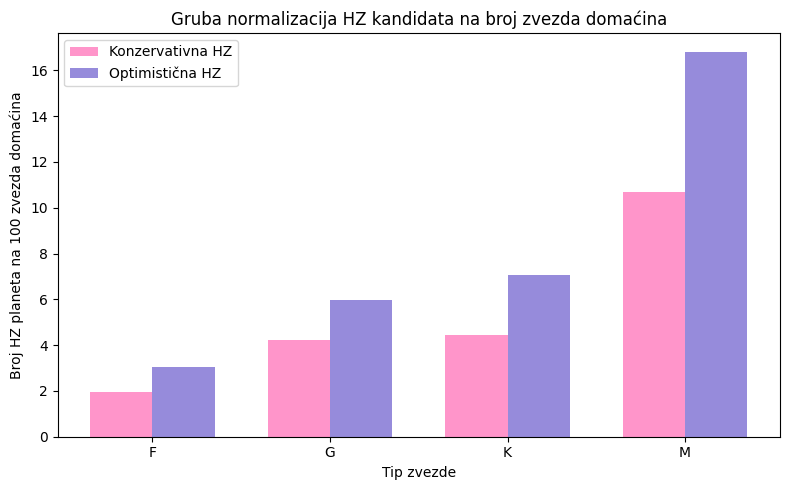

In [78]:
types = occurrence_by_type.index
x = np.arange(len(types))
WIDTH = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - WIDTH / 2,
    occurrence_by_type["conservative_per_100_stars"],
    WIDTH,
    alpha=0.7,
    color="hotpink",
    label="Konzervativna HZ",
)

plt.bar(
    x + WIDTH / 2,
    occurrence_by_type["optimistic_per_100_stars"],
    WIDTH,
    alpha=0.7,
    color="slateblue",
    label="Optimistična HZ",
)

plt.xticks(x, types)
plt.xlabel("Tip zvezde")
plt.ylabel("Broj HZ planeta na 100 zvezda domaćina")
plt.title("Gruba normalizacija HZ kandidata na broj zvezda domaćina")
plt.legend()
plt.tight_layout()
plt.show()

#### **Bootstrap po tipu zvezde**

Kao i u prethodnoj analizi, kako su procenti udela računati iz konačnog broja planeta u svakoj klasi gde različite klase nemaju isti broj objekata. Na primer, u uzorku ima mnogo više planeta oko G zvezda nego oko M zvezda, pa procenti dobijeni za ove klase nemaju istu statističku pouzdanost. Zbog toga nije dovoljno samo uporediti dobijene vrednosti procenata, već je potrebno proceniti i koliko su ti procenti stabilni u okviru svake spektralne klase.

Bootstrap analiza po tipu zvezde uvodi upravo tu procenu neizvesnosti. Za svaku klasu zvezda posebno se formiraju novi uzorci, izvlačenjem planeta sa ponavljanjem iz odgovarajuće grupe, i za svaki takav uzorak ponovo se računa udeo planeta u konzervativnoj i optimističnoj habitabilnoj zoni. Na taj način se za svaki spektralni tip ne dobija samo jedna vrednost procenta, već raspodela mogućih vrednosti tog procenta. Iz te raspodele mogu se odrediti standardna greška i interval pouzdanosti za udeo HZ kandidata u svakoj grupi.

In [70]:
stellar_types = ["M", "K", "G", "F"]

results = []

for stype in stellar_types:
    subset = df_clean[df_clean["stellar_type"] == stype]

    boot_cons = bootstrap_fraction(
        subset,
        "in_conservative_hz",
        n_bootstrap=5000,
    )

    boot_opt = bootstrap_fraction(
        subset,
        "in_optimistic_hz",
        n_bootstrap=5000,
    )

    results.append(
        {
            "stellar_type": stype,
            "N_total": len(subset),
            "cons_mean": np.mean(boot_cons),
            "cons_std": np.std(boot_cons, ddof=1),
            "cons_low_95": np.percentile(boot_cons, 2.5),
            "cons_high_95": np.percentile(boot_cons, 97.5),
            "opt_mean": np.mean(boot_opt),
            "opt_std": np.std(boot_opt, ddof=1),
            "opt_low_95": np.percentile(boot_opt, 2.5),
            "opt_high_95": np.percentile(boot_opt, 97.5),
        }
    )

stellar_bootstrap_summary = pd.DataFrame(results)

stellar_bootstrap_summary.round(3)

,stellar_type,N_total,cons_mean,cons_std,cons_low_95,cons_high_95,opt_mean,opt_std,opt_low_95,opt_high_95
0,M,531,0.075,0.011,0.053,0.098,0.119,0.014,0.092,0.147
1,K,1413,0.032,0.005,0.023,0.042,0.052,0.006,0.040,0.064
2,G,2538,0.031,0.003,0.025,0.038,0.044,0.004,0.037,0.052
3,F,1042,0.015,0.004,0.009,0.023,0.024,0.005,0.015,0.034


In [71]:
stellar_bootstrap_summary["cons_mean_percent"] = (
    100 * stellar_bootstrap_summary["cons_mean"]
)

stellar_bootstrap_summary["cons_std_percent"] = (
    100 * stellar_bootstrap_summary["cons_std"]
)

stellar_bootstrap_summary["opt_mean_percent"] = (
    100 * stellar_bootstrap_summary["opt_mean"]
)

stellar_bootstrap_summary["opt_std_percent"] = (
    100 * stellar_bootstrap_summary["opt_std"]
)

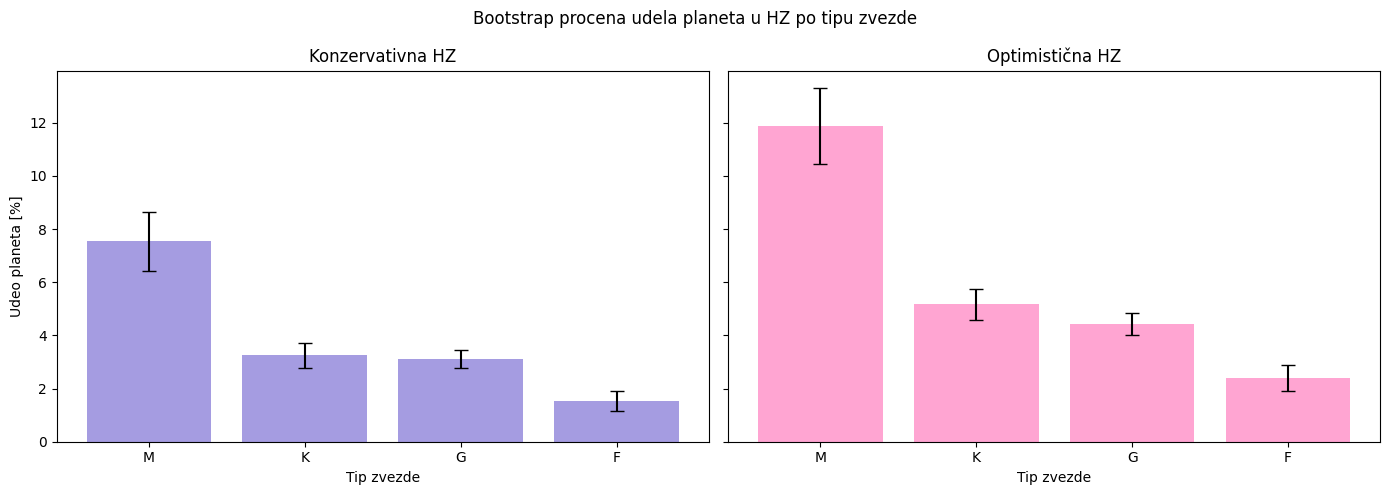

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

x = stellar_bootstrap_summary["stellar_type"]

axes[0].bar(
    x,
    stellar_bootstrap_summary["cons_mean_percent"],
    yerr=stellar_bootstrap_summary["cons_std_percent"],
    color="slateblue",
    alpha=0.6,
    capsize=5,
)
axes[0].set_xlabel("Tip zvezde")
axes[0].set_ylabel("Udeo planeta [%]")
axes[0].set_title("Konzervativna HZ")

axes[1].bar(
    x,
    stellar_bootstrap_summary["opt_mean_percent"],
    yerr=stellar_bootstrap_summary["opt_std_percent"],
    color="hotpink",
    alpha=0.6,
    capsize=5,
)
axes[1].set_xlabel("Tip zvezde")
axes[1].set_title("Optimistična HZ")

fig.suptitle("Bootstrap procena udela planeta u HZ po tipu zvezde")

plt.tight_layout()
plt.show()

Iz prethodno dobijene tabele može se primetiti da je pouzdanost procene različita za različite spektralne tipove što je i očekivano razmatrajući veličinu posmatranog uzorka. Dobijeno je da je za konzervativnu HZ kod M zvezda neodređenost oko $3.3$ puta veća nego kod G zvezda, slično i za optimističnu gde je $3.42$ puta.

## **Analiza po metodi detekcije**

Kako je poređenje po tipu zvezde pokazalo da je najveći udeo HZ prisutan kod zvezda M klase. Međutim, daljim ispitivanjem dostupnih podataka je takođe zaključena neravnomernost u podacima kada je reč o velikoj poluosi, odnosno favorizovane su niže vrednosti $a$. Najverovatniji razlog tome jeste priroda tranzitnih posmatranja i naklonost ka kraćim periodima posmatranja.

Iako najzastupljenija metoda otkrivanja egzoplaneta jeste metoda tranzita, odnosno analize krive sjaja, pored nje postoji još značajnih metoda. Neke od njih koje se mogu naći i u ovoj bazi podataka jesu metoda radijalnih brzina, imaging, TTV, ETV, astrometrija i microlensing. Uzimajući u obzir veličinu uzorka za svaku od njih koja se nalazi odmah u sledećoj ćeliji, za poredbenu metodu uzima se RV.  

Metoda radijalnih brzina se zasniva na posmatranju promene u spektralnim linijama usled gravitacionog uticaja drugog tela na zvezdu, odnosno usled izmeštanja centra mase. Ponovo, slično kao i kod tranzitne metode, što je planeta bliža zvezdi, gravitacioni uticaj pa samim tim i Doplerov pomak će iskazati jači signal. Takođe, za potvrđenu egzoplanetu je potrebno više ispunjenih celih orbita što za planete daleko od centralne zvezde može da traje godinama. Jedina metoda koja favorizuje veće udaljenosti od zvezde jeste "Imaging" jer ih detektuje ukoliko može zapravo direktno da ih razdvoji. Nažalost, prepreka u vidu prevelikog sjaja koji zaklanja tamnu planetu postoji, zbog čega se na prvom dobijenom grafiku može uvideti da je nađen manji broj planeta oko toplijih zvezda nego hladnijih. 


In [73]:
# Broj planeta po načinu detekcije
method_counts = df_clean["discoverymethod"].value_counts()

print(method_counts)

discoverymethod
Transit                          4273
Radial Velocity                  1151
Imaging                            57
Transit Timing Variations          35
Astrometry                          3
Eclipse Timing Variations           3
Orbital Brightness Modulation       1
Microlensing                        1
Name: count, dtype: int64


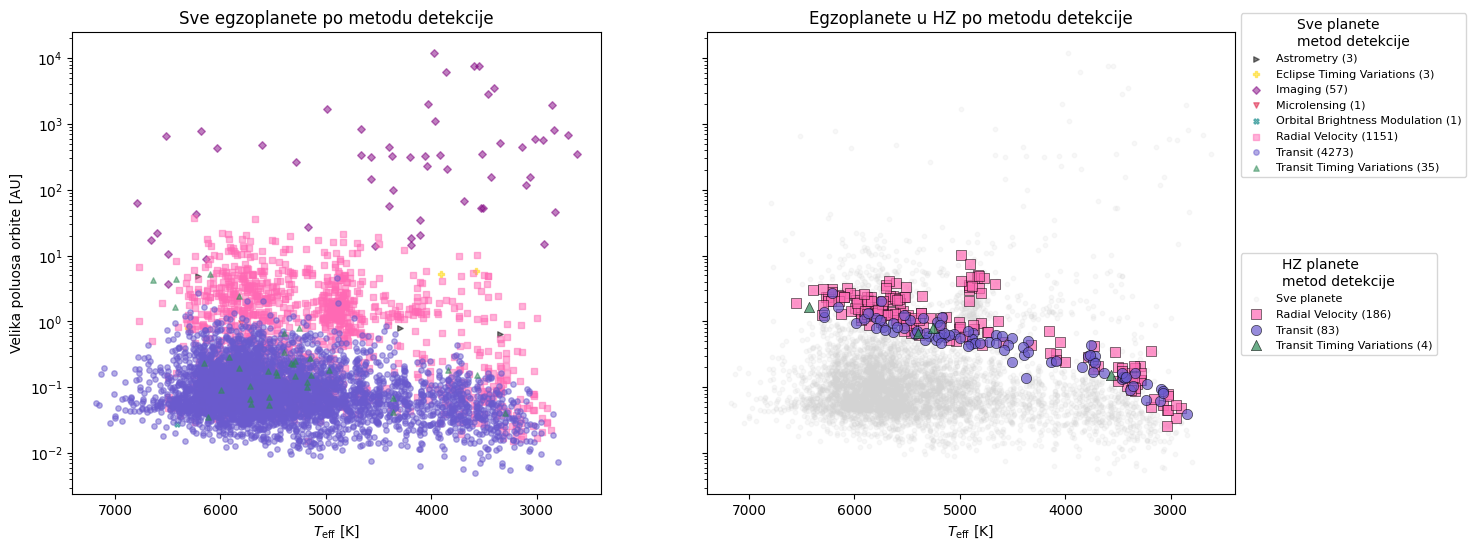

Text(0.5, 0.98, 'Poređenje metoda detekcije za sve planete i HZ kandidate')

<Figure size 640x480 with 0 Axes>

In [74]:
# Biramo samo planete koje imaju metod detekcije
df_plot = df_clean.dropna(subset=["discoverymethod"]).copy()

# Obe HZ
hz_mask = df_plot["in_optimistic_hz"]  # optimistična HZ
# hz_mask = df_plot["in_conservative_hz"]    # konzervativna HZ

df_hz = df_plot[hz_mask].copy()

# Metode detekcije
methods = sorted(df_plot["discoverymethod"].unique())


colors = {
    "Transit": "slateblue",
    "Radial Velocity": "hotpink",
    "Transit Timing Variations": "seagreen",
    "Imaging": "purple",
    "Microlensing": "crimson",
    "Eclipse Timing Variations": "gold",
    "Orbital Brightness Modulation": "teal",
    "Pulsar Timing": "brown",
    "Pulsation Timing Variations": "deeppink",
    "Astrometry": "black",
    "Disk Kinematics": "gray",
}


markers = {
    "Transit": "o",
    "Radial Velocity": "s",
    "Transit Timing Variations": "^",
    "Imaging": "D",
    "Microlensing": "v",
    "Eclipse Timing Variations": "P",
    "Orbital Brightness Modulation": "X",
    "Pulsar Timing": "*",
    "Pulsation Timing Variations": "<",
    "Astrometry": ">",
    "Disk Kinematics": "h",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Sve planete kategorisane po metodi pronalaska
for method in methods:
    sub = df_plot[df_plot["discoverymethod"] == method]

    axes[0].scatter(
        sub["st_teff"],
        sub["pl_orbsmax"],
        s=15,
        alpha=0.5,
        color=colors.get(method, "gray"),
        marker=markers.get(method, "o"),
        label=f"{method} ({len(sub)})",
    )

axes[0].set_xlabel(r"$T_{\mathrm{eff}}$ [K]")
axes[0].set_ylabel("Velika poluosa orbite [AU]")
axes[0].set_yscale("log")
axes[0].invert_xaxis()
axes[0].set_title("Sve egzoplanete po metodu detekcije")


axes[1].scatter(
    df_plot["st_teff"],
    df_plot["pl_orbsmax"],
    s=10,
    alpha=0.15,
    color="lightgray",
    label="Sve planete",
)

# Samo HZ planete po metodu detekcije
for method in methods:
    sub_hz = df_hz[df_hz["discoverymethod"] == method]

    if len(sub_hz) == 0:
        continue

    axes[1].scatter(
        sub_hz["st_teff"],
        sub_hz["pl_orbsmax"],
        s=55,
        alpha=0.7,
        color=colors.get(method, "gray"),
        marker=markers.get(method, "o"),
        edgecolor="black",
        linewidth=0.5,
        label=f"{method} ({len(sub_hz)})",
    )

axes[1].set_xlabel(r"$T_{\mathrm{eff}}$ [K]")
axes[1].set_yscale("log")
axes[1].invert_xaxis()
axes[1].set_title("Egzoplanete u HZ po metodu detekcije")


# Legende
handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()


fig.legend(
    handles0,
    labels0,
    title="Sve planete\nmetod detekcije",
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.90, 0.92),
)


fig.legend(
    handles1,
    labels1,
    title="HZ planete\nmetod detekcije",
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.90, 0.52),
)


plt.show()
plt.tight_layout()
plt.suptitle("Poređenje metoda detekcije za sve planete i HZ kandidate")

Iz gore prikazanog grafika se može jasno videti da od svih metoda detekcije samo uzorci snimani RV, tranzitnom i TTV metodom imaju kandidate koji pripadaju optimističnoj habitabilnoj zoni. Zbog toga se iz razmatranja definitivno odbacuje prethodno pomenuta Imaging metoda sa većim brojem kandidata za veće $a$ i za poredbenu bira se RV metoda. Razlog tome može biti to što je većina njih na udaljenosti od $10^3 AU$ za najveći broj uzoraka koji se nalazi oko M zvezde a kod toplijih zvezda ima samo oko 10 uzoraka. Takođe, planete na udaljenosti $\sim 10^2 AU$ do efektivne temperature od $5000 K$ nema uzoraka.

Takođe, još jedna zanimljiva informacija jeste da je u odnosu na broj detektovanih tranzitnih planeta, broj njih koji pripadaju HZ dosta manja od broja koji pripada HZ od RV planeta.


In [ ]:
# Definišemo funkciju koja će za svaki tip zvezde sumarizovati koliko ukupno ima
#  planeta i koliko ih je u kojoj kategoriji HZ (i koliki je %)
def hz_summary_by_type(data):
    """Sumarizuje broj i udeo planeta u habitabilnoj zoni prema spektralnom tipu."""
    summary = data.groupby("stellar_type").agg(
        N_total=("pl_name", "count"),
        N_conservative=("in_conservative_hz", "sum"),
        N_optimistic=("in_optimistic_hz", "sum"),
    )

    summary["f_conservative[%]"] = 100 * summary["N_conservative"] / summary["N_total"]

    summary["f_optimistic[%]"] = 100 * summary["N_optimistic"] / summary["N_total"]

    return summary

In [76]:
df_transit = df_clean[df_clean["discoverymethod"] == "Transit"].copy()

df_rv = df_clean[df_clean["discoverymethod"] == "Radial Velocity"].copy()

summary_transit = hz_summary_by_type(df_transit)
summary_rv = hz_summary_by_type(df_rv)

print("TRANZITNA METODA")
display(summary_transit.round(2))

print("METODA RADIJALNE BRZINE")
display(summary_rv.round(2))

TRANZITNA METODA


,N_total,N_conservative,N_optimistic,f_conservative[%],f_optimistic[%]
stellar_type,,,,,
F,900,2,4,0.22,0.44
G,2057,9,24,0.44,1.17
K,978,17,31,1.74,3.17
M,338,15,24,4.44,7.10


METODA RADIJALNE BRZINE


,N_total,N_conservative,N_optimistic,f_conservative[%],f_optimistic[%]
stellar_type,,,,,
F,123,14,20,11.38,16.26
G,459,69,86,15.03,18.74
K,404,29,42,7.18,10.40
M,165,25,38,15.15,23.03


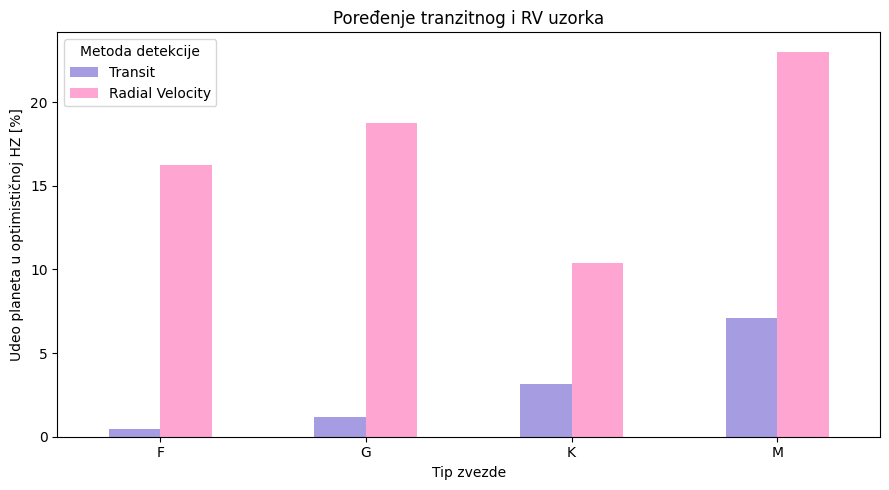

In [77]:
comparison_plot = pd.DataFrame(
    {
        "Transit": summary_transit["f_optimistic[%]"],
        "Radial Velocity": summary_rv["f_optimistic[%]"],
    }
)

comparison_plot = comparison_plot.reindex(["F", "G", "K", "M"])

comparison_plot.plot(
    kind="bar", figsize=(9, 5), alpha=0.6, color=["slateblue", "hotpink"]
)

plt.xlabel("Tip zvezde")
plt.ylabel("Udeo planeta u optimističnoj HZ [%]")
plt.title("Poređenje tranzitnog i RV uzorka")
plt.legend(title="Metoda detekcije")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **_Zaključak_**

Rezultat ove analize sadrži tri bitne informacije. Prva jeste da metod detekcije snažno utiče na procenjeni udeo kandidata koji pripadaju HZ gde je RV metoda dala poprilično veće procente od tranzitne. Sledeća jeste da i spektralni tip utiče na rezultat gde se kod tranzitne vidi rast od F ka M zvezdama a kod RV su najveći udeli kod G i M tipa zvezda. Takođe bitna stvar jeste da je i nakon analize putem metode detekcije pokazano da je kod M zvezda najveći udeo planeta pripadnik habitabilne zone. 

Slična pitanja razmatrana su i u radu _Jiang et al. (2024)_, gde je analizirana habitabilnost potvrđenih egzoplaneta iz NASA Exoplanet Archive kataloga, uz poseban osvrt na spektralni tip zvezde domaćina i pristrasnosti metoda detekcije. Međutim, njihova klasifikacija habitabilne zone zasniva se na procenjenoj prosečnoj površinskoj temperaturi planete i granicama od 0 do 100 °C (odnosno osnovnog eliminacionog faktora, temperaturama na kojima se voda ne nalazi u tečnom stanju), dok se u ovom radu koriste Kopparapu granice habitabilne zone, odnosno odvojeno se razmatraju konzervativna i optimistična HZ.

Rezultati ovog rada kvalitativno su u saglasnosti sa _Jiang et al. (2024)_, jer i ovde RV metoda daje veći broj HZ kandidata u odnosu na tranzitnu metodu. Ipak, doprinos ove analize nije u samom uočavanju RV-Tranzit razlike, već u tome što je ista pojava proverena pomoću Kopparapu modela i dodatno statistički ispitana bootstrap metodom i Monte Carlo propagacijom grešaka. Bootstrap analiza procenjuje stabilnost ukupnog udela HZ kandidata u konačnom uzorku, dok Monte Carlo analiza ispituje koliko je klasifikacija pojedinačnih planeta stabilna kada se uzmu u obzir merne neizvesnosti parametara.

Za razliku od _Jiang et al. (2024)_, gde se naglašava apsolutna raspodela HZ planeta po spektralnim klasama, u ovom radu posmatran je i relativni udeo HZ kandidata unutar svake klase zvezda. U tom poređenju M zvezde pokazuju najveći procenat planeta u habitabilnoj zoni, iako nemaju najveći apsolutni broj detektovanih planeta u uzorku.

Ovaj rezultat može se objasniti položajem habitabilne zone u odnosu na raspodelu detektovanih orbitalnih udaljenosti. Kod hladnijih i manje luminoznih M zvezda Kopparapu habitabilna zona nalazi se znatno bliže zvezdi nego kod F, G i K zvezda. Pošto je posmatrački katalog bogat planetama na malim orbitalnim udaljenostima, veći deo planeta oko toplijih zvezda nalazi se unutra od unutrašnje granice HZ. Nasuprot tome, slične orbitalne udaljenosti oko M zvezda češće se poklapaju sa njihovom bližom habitabilnom zonom.

Ipak, veći relativni udeo HZ kandidata oko M zvezda ne treba tumačiti kao dokaz da se habitabilne planete u Galaksiji najčešće nalaze oko M zvezda. M zvezde jesu najzastupljeniji tip zvezda u Galaksiji, ali su u katalozima potvrđenih egzoplaneta slabije zastupljene u odnosu na svoju stvarnu učestalost. Zbog toga analizirani NASA katalog nije reprezentativan uzorak svih zvezda i planeta u Galaksiji, već uzorak detektovanih i potvrđenih egzoplaneta, oblikovan selekcionim efektima metoda detekcije. Da bi se izveo zaključak o stvarnoj učestalosti HZ planeta oko različitih tipova zvezda, bilo bi potrebno normalizovati broj HZ planeta na ukupan broj posmatranih zvezda svakog tipa, uključujući i zvezde kod kojih planete nisu detektovane. U ovom radu se zato dobijeni rezultat tumači kao osobina analiziranog kataloga, a ne kao potpuna procena galaktičke učestalosti habitabilnih planeta.

Dodatno, iako M zvezde u ovom uzorku imaju najveći relativni udeo HZ kandidata, položaj u Kopparapu habitabilnoj zoni nije dovoljan uslov za stvarnu habitabilnost. Habitabilna zona oko M zvezda nalazi se veoma blizu zvezde, što može dovesti do plimskog zaključavanja planete, jačeg uticaja zvezdane aktivnosti i povišene izloženosti zračenju viših energija kao i mogućeg gubitka atmosfere. Pored toga, HZ oko M zvezda je uža, pa su klasifikacije osetljivije na greške u parametrima. Zbog toga se M zvezde ne mogu jednostavno proglasiti najpovoljnijim za habitabilnost, iako u detektovanom katalogu pokazuju veliki relativni udeo planeta unutar Kopparapu granica.

Zbog toga veći relativni udeo HZ kandidata oko M zvezda treba tumačiti prvenstveno kao posledicu preklapanja Kopparapu granica habitabilne zone, koje zavise od temperature i luminoznosti zvezde, sa selekciono oblikovanom raspodelom detektovanih orbitalnih udaljenosti u NASA katalogu. Zaključno, ovaj rad pokazuje da procena habitabilnih kandidata zavisi ne samo od fizičkih parametara sistema, već i od načina detekcije, strukture kataloga i izabrane definicije habitabilne zone.


#### **Literatura**

Kopparapu, R. K., Ramirez, R. M., SchottelKotte, J., Kasting, J. F., Domagal-Goldman, S., & Eymet, V. (2014). Habitable zones around main-sequence stars: Dependence on planetary mass. The Astrophysical Journal Letters, 787(2), L29. https://doi.org/10.1088/2041-8205/787/2/L29

Jiang, J. H., Rosen, P. E., Liu, C. X., Wen, Q., & Chen, Y. (2024). Analysis of habitability and stellar habitable zones from observed exoplanets. Galaxies, 12(6), 86. https://doi.org/10.3390/galaxies12060086